Problem Statement:
 The raw dataset contained missing values and inconsistent data types making it difficult to extract meaningful
 insights about EV trends, CAFV eligibility and regional growth.

**Import Library**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

**Import Data**

This dataset shows the Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) that are currently registered through Washington State Department of Licensing.

In [2]:
df = pd.read_csv("C:\\Users\\suren\\Downloads\\Electric_Vehicle_Population_Data.csv")

**Quickview of the data**

In [3]:
df.head()

,VIN (1-10),County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,Vehicle Location,Electric Utility,2020 Census Tract
0,5YJ3E1EBXK,King,Seattle,WA,98178.0,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220.0,0.0,37.0,477309682,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,5YJYGDEE3L,Kitsap,Poulsbo,WA,98370.0,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291.0,0.0,23.0,109705683,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10
2,KM8KRDAF5P,Kitsap,Olalla,WA,98359.0,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,0.0,0.0,26.0,230390492,POINT (-122.54729 47.42602),PUGET SOUND ENERGY INC,5.303509e+10
3,5UXTA6C0XM,Kitsap,Seabeck,WA,98380.0,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30.0,0.0,35.0,267929112,POINT (-122.81585 47.64509),PUGET SOUND ENERGY INC,5.303509e+10
4,JTMAB3FV7P,Thurston,Rainier,WA,98576.0,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42.0,0.0,2.0,236505139,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,5.306701e+10


****

**Data Structure**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235692 entries, 0 to 235691
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         235692 non-null  object 
 1   County                                             235689 non-null  object 
 2   City                                               235689 non-null  object 
 3   State                                              235692 non-null  object 
 4   Postal Code                                        235689 non-null  float64
 5   Model Year                                         235692 non-null  int64  
 6   Make                                               235692 non-null  object 
 7   Model                                              235692 non-null  object 
 8   Electric Vehicle Type                              235692 non-null  object

****

**checking null values**

In [5]:
df.isnull().sum()

VIN (1-10)                                             0
County                                                 3
City                                                   3
State                                                  0
Postal Code                                            3
Model Year                                             0
Make                                                   0
Model                                                  0
Electric Vehicle Type                                  0
Clean Alternative Fuel Vehicle (CAFV) Eligibility      0
Electric Range                                        36
Base MSRP                                             36
Legislative District                                 494
DOL Vehicle ID                                         0
Vehicle Location                                      10
Electric Utility                                       3
2020 Census Tract                                      3
dtype: int64

****

**Summary of data**

In [6]:
df.describe()

,Postal Code,Model Year,Electric Range,Base MSRP,Legislative District,DOL Vehicle ID,2020 Census Tract
count,235689.000000,235692.000000,235656.000000,235656.000000,235198.000000,2.356920e+05,2.356890e+05
mean,98177.656463,2021.406658,46.262569,787.268328,28.879519,2.353127e+08,5.298066e+10
std,2524.218661,2.991908,84.045829,7177.668305,14.904644,6.799098e+07,1.521066e+09
min,1731.000000,2000.000000,0.000000,0.000000,1.000000,4.385000e+03,1.001020e+09
25%,98052.000000,2020.000000,0.000000,0.000000,17.000000,2.053457e+08,5.303301e+10
50%,98126.000000,2023.000000,0.000000,0.000000,32.000000,2.522795e+08,5.303303e+10
75%,98374.000000,2024.000000,38.000000,0.000000,42.000000,2.696401e+08,5.305307e+10
max,99577.000000,2025.000000,337.000000,845000.000000,49.000000,4.792548e+08,5.602100e+10


****

**Data Cleaning**


**Remove unwanted columns**

In [77]:
EVP_df = df.drop(['VIN (1-10)','DOL Vehicle ID'],axis=1)  # Drop identifiers

**Replace Null values**

In [117]:
Missing_cols = ['County', 'City', 'Electric Utility','Vehicle Location']  #create list of column names

In [118]:
EVP_df[Missing_cols] = EVP_df[Missing_cols].fillna("Unknown")  # Fill missing categorical values with "Unknown"

In [180]:
# EVP_df.isnull().sum()

****

**Fill Null numeric Values with mean**

# EVP_df['Electric Range'].mean()  #calculate the mean 

In [84]:
EVP_df['Electric Range'].fillna(EVP_df['Electric Range'].mean(),inplace=True)  #replaces missing values with mean

In [108]:
EVP_df['Electric Range'] = EVP_df['Electric Range'].astype(int)   #convert the data type float to integer 

In [128]:
EVP_df['Base MSRP'].mean()  #calculate the mean 

1563.5505990455015

In [87]:
EVP_df['Base MSRP'].fillna(EVP_df['Base MSRP'].mean(),inplace=True)  #replaces missing values with mean

****

**CAFV Eligibility into 3 categories using custom function**

In [94]:
def cafv(value):        #takes a single cell value and returns one 
    value = str(value).lower()    #Converts the value to a string and to lowercase to make comparisons case-insensitive.
    if "eligible" in value and "not" not in value:  #Checks substring eligible exists and substring not does not exist.
        return "Eligible" 
    elif "not eligible" in value:  #Checks substring not eligible exists.
        return "Not Eligible"
    else:
        return "Unknown"    

In [17]:
EVP_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'] = EVP_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].apply(cafv) 

In [18]:
EVP_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts() 

Clean Alternative Fuel Vehicle (CAFV) Eligibility
Unknown         139761
Eligible         73317
Not Eligible     22614
Name: count, dtype: int64

****

**Fill Null numeric Values with median**

In [88]:
EVP_df['Legislative District'].median()  #calculate the median

32.0

In [89]:
EVP_df['Legislative District'].fillna(EVP_df['Legislative District'].median(),inplace=True)  #replaces missing values with median

In [90]:
EVP_df['Legislative District'] = EVP_df['Legislative District'].astype(int)  #convert the data type float to integer

In [91]:
EVP_df['2020 Census Tract'].median()  #calculate the median

53033030310.0

In [93]:
EVP_df['2020 Census Tract'].fillna(EVP_df['2020 Census Tract'].median(),inplace=True)  #replaces missing values with median

In [123]:
EVP_df['Postal Code'].median()  #calculate the median

98126.0

In [124]:
EVP_df['Postal Code'].fillna(EVP_df['Postal Code'].median(),inplace=True)  #replaces missing values with median

In [125]:
EVP_df['Postal Code'] = EVP_df['Postal Code'].astype(int)  #convert the data type float to integer

****

**Replace 0 values with mean**

In [111]:
MSRP_mean = EVP_df['Base MSRP'].mean()  #Create new variable to store mean

In [100]:
MSRP_mean 

787.2683275622095

In [112]:
EVP_df['Base MSRP'] = EVP_df['Base MSRP'].replace(0,MSRP_mean)   #Find values equal to 0 and replace with mean.

In [129]:
Rang_mean = EVP_df['Electric Range'].mean()  #Create new variable to store mean

In [130]:
Rang_mean

73.53967890297507

In [131]:
EVP_df['Electric Range'] = EVP_df['Electric Range'].replace(0,Rang_mean)  #Find values equal to 0 and replace with mean.

****

**Data Clean Successfully**

In [126]:
EVP_df.isnull().sum()

County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64

In [127]:
EVP_df.head()

,County,City,State,Postal Code,Model Year,Make,Model,Electric Vehicle Type,Clean Alternative Fuel Vehicle (CAFV) Eligibility,Electric Range,Base MSRP,Legislative District,Vehicle Location,Electric Utility,2020 Census Tract
0,King,Seattle,WA,98178,2019,TESLA,MODEL 3,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,220,787.268328,37,POINT (-122.23825 47.49461),CITY OF SEATTLE - (WA)|CITY OF TACOMA - (WA),5.303301e+10
1,Kitsap,Poulsbo,WA,98370,2020,TESLA,MODEL Y,Battery Electric Vehicle (BEV),Clean Alternative Fuel Vehicle Eligible,291,787.268328,23,POINT (-122.64681 47.73689),PUGET SOUND ENERGY INC,5.303509e+10
2,Kitsap,Olalla,WA,98359,2023,HYUNDAI,IONIQ 5,Battery Electric Vehicle (BEV),Eligibility unknown as battery range has not b...,46,787.268328,26,POINT (-122.54729 47.42602),PUGET SOUND ENERGY INC,5.303509e+10
3,Kitsap,Seabeck,WA,98380,2021,BMW,X5,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,30,787.268328,35,POINT (-122.81585 47.64509),PUGET SOUND ENERGY INC,5.303509e+10
4,Thurston,Rainier,WA,98576,2023,TOYOTA,RAV4 PRIME,Plug-in Hybrid Electric Vehicle (PHEV),Clean Alternative Fuel Vehicle Eligible,42,787.268328,2,POINT (-122.68993 46.88897),PUGET SOUND ENERGY INC,5.306701e+10


** **

**Data Visualization**

**States Wise Count Of EV population**

In [38]:
state_counts = EVP_df['State'].value_counts()

In [39]:
state_counts.head(10)

State
WA    235198
CA       112
VA        62
MD        38
TX        28
CO        21
FL        19
NC        18
GA        15
AZ        11
Name: count, dtype: int64

****

**Years that have the most vehicles**

In [168]:
Highest_Years = EVP_df['Model Year'].value_counts()

In [170]:
Highest_Years.head(10)

Model Year
2023    59893
2024    49044
2022    28958
2021    20615
2018    14368
2020    12265
2025    11176
2019    10974
2017     8570
2016     5306
Name: count, dtype: int64

** **

**Distribution of EV Types**

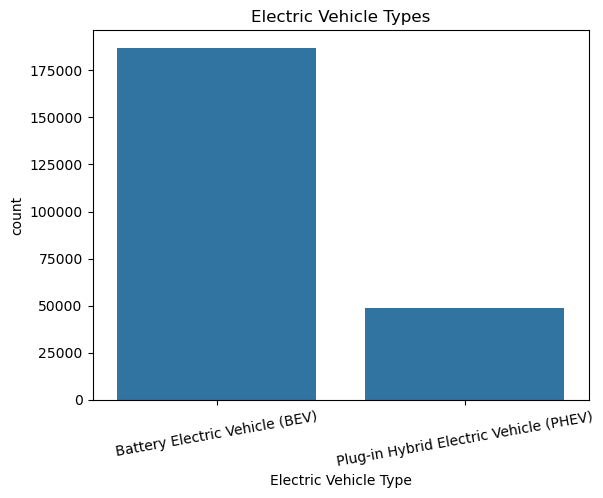

In [40]:
sns.countplot(data=EVP_df, x="Electric Vehicle Type", order=EVP_df["Electric Vehicle Type"].value_counts().index)
plt.title("Electric Vehicle Types")
plt.xticks(rotation=10)
plt.show()

**  **

**Distribution of Model Years**

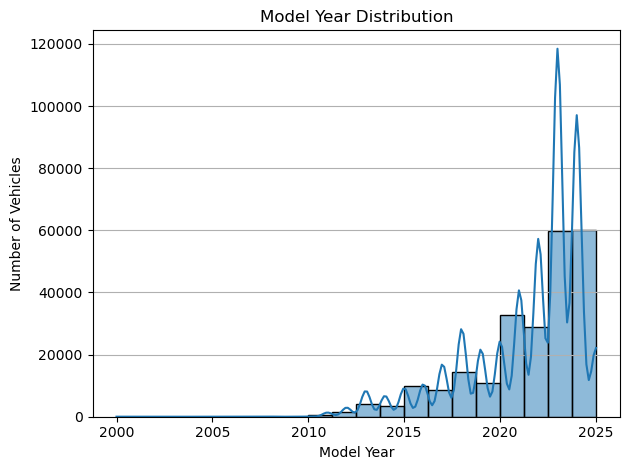

In [156]:
sns.histplot(EVP_df['Model Year'], bins=20, kde=True)
plt.title('Model Year Distribution')
plt.xlabel('Model Year')
plt.ylabel('Number of Vehicles')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

** **

**Top 10 EV Manufacturers**

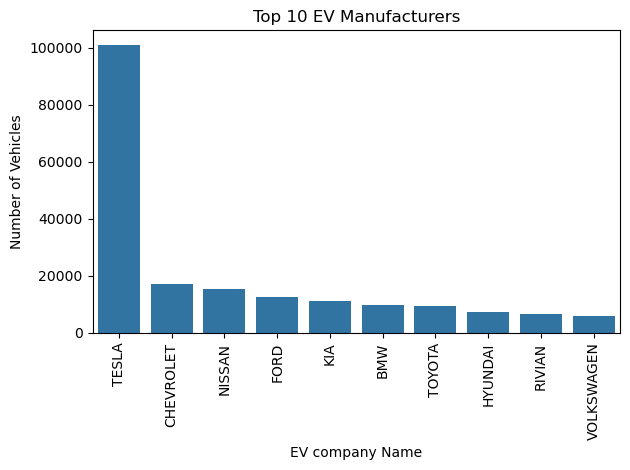

In [46]:
Top_EV_Makers= EVP_df['Make'].value_counts().head(10)
sns.barplot(data=Top_EV_Makers)
plt.title("Top 10 EV Manufacturers")
plt.xlabel("EV company Name")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

** **

**Top 10 EV Models**

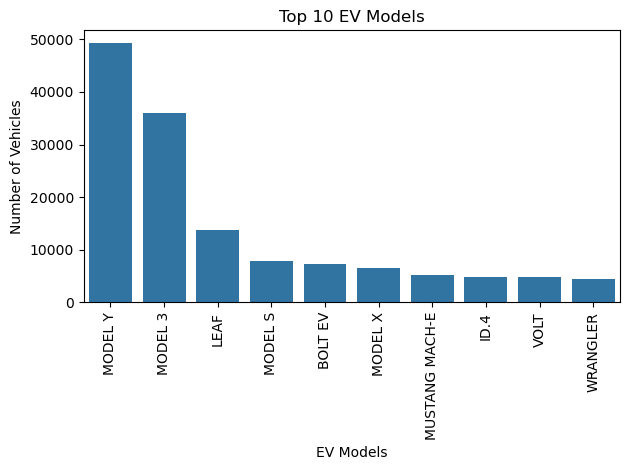

In [47]:
Top_EV_Models= EVP_df['Model'].value_counts().head(10)
sns.barplot(data=Top_EV_Models)
plt.title("Top 10 EV Models")
plt.xlabel("EV Models")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

** **

**Top 10 Cities with most EV**

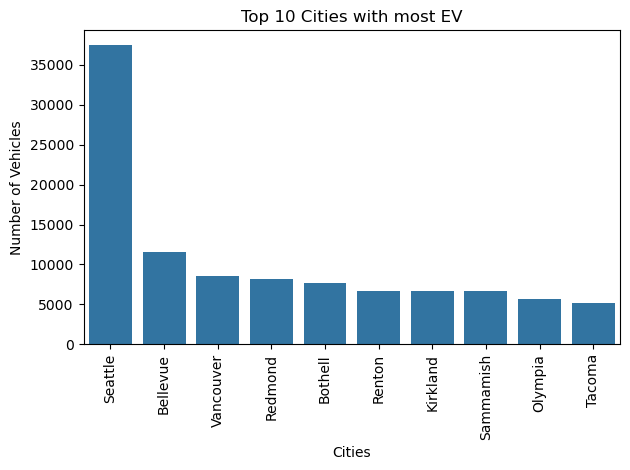

In [48]:
Top_EV_City= EVP_df['City'].value_counts().head(10)
sns.barplot(data=Top_EV_City)
plt.title("Top 10 Cities with most EV")
plt.xlabel("Cities")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

** **

**Top 10 County with most EV**

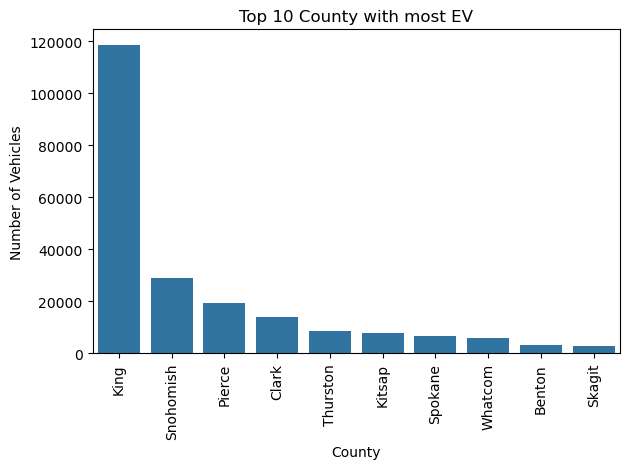

In [49]:
Top_EV_County= EVP_df['County'].value_counts().head(10)
sns.barplot(data=Top_EV_County)
plt.title("Top 10 County with most EV")
plt.xlabel("County")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

** **

**Overall Eligibility of CAFV**

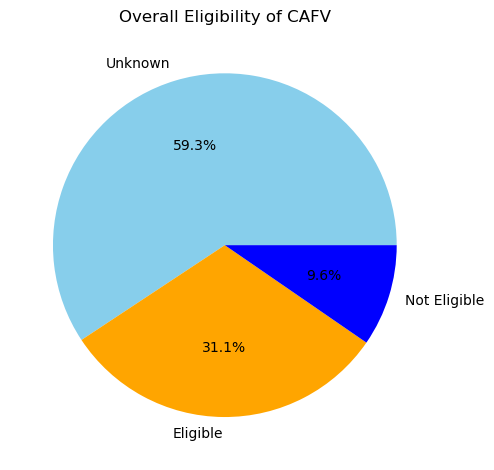

In [50]:
cafv_Eligibility= EVP_df['Clean Alternative Fuel Vehicle (CAFV) Eligibility'].value_counts()
plt.pie(cafv_Eligibility,labels=cafv_Eligibility.index,autopct='%1.1f%%',colors=['skyblue', 'orange','blue'] ) 
plt.title('Overall Eligibility of CAFV')
plt.tight_layout()
plt.show()

** **

**Top 10 BEV Type Makers**

In [51]:
BEV_df = EVP_df[EVP_df["Electric Vehicle Type"].str.contains("Battery Electric Vehicle")]

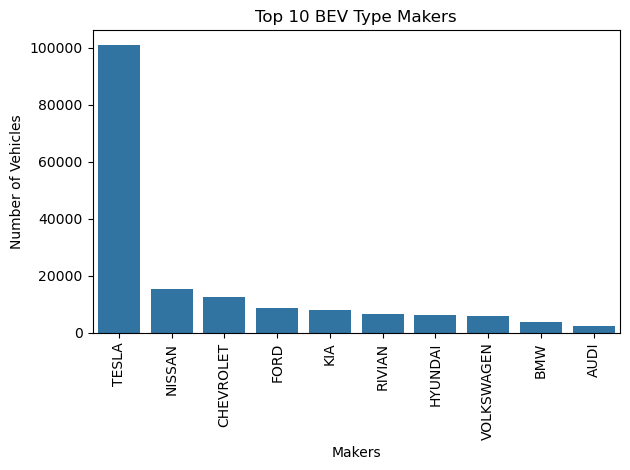

In [52]:
Top_BEV_Type_Makers= BEV_df['Make'].value_counts().head(10)
sns.barplot(data=Top_BEV_Type_Makers)
plt.title("Top 10 BEV Type Makers")
plt.xlabel("Makers")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

** **

**Top 10 PHEV Type Makers**

In [53]:
PHEV_df = EVP_df[EVP_df["Electric Vehicle Type"].str.contains("Plug-in Hybrid Electric Vehicle")]

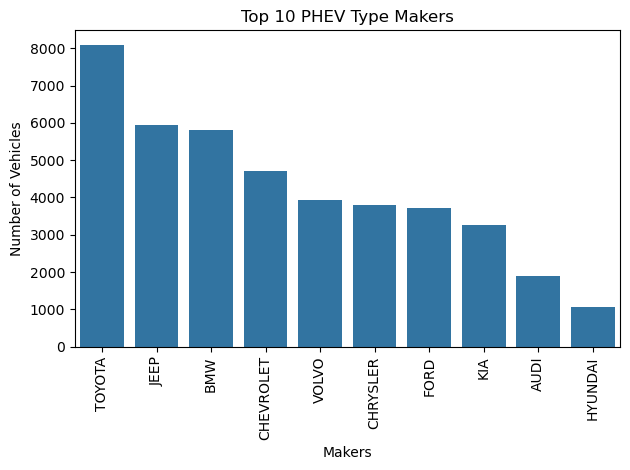

In [54]:
Top_PHEV_Type_Makers= PHEV_df['Make'].value_counts().head(10)
sns.barplot(data=Top_PHEV_Type_Makers)
plt.title("Top 10 PHEV Type Makers")
plt.xlabel("Makers")
plt.ylabel("Number of Vehicles")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

** **

**10 Years EV Population**

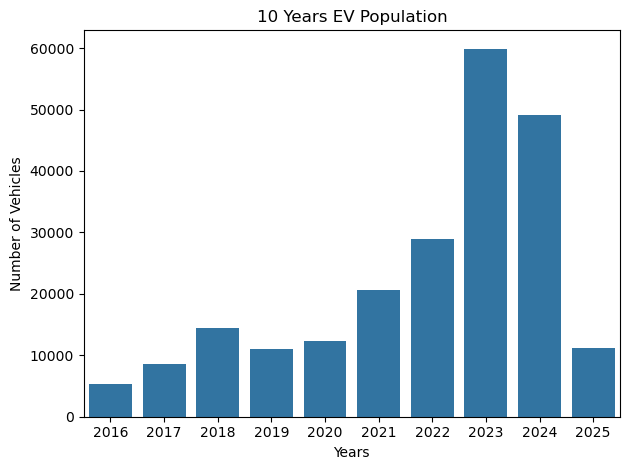

In [55]:
Year_EV= EVP_df['Model Year'].value_counts().head(10)
sns.barplot(data=Year_EV)
plt.title("10 Years EV Population")
plt.xlabel("Years")
plt.ylabel("Number of Vehicles")
plt.tight_layout()
plt.show()

** **

**Electric Range vs Base MSRP**

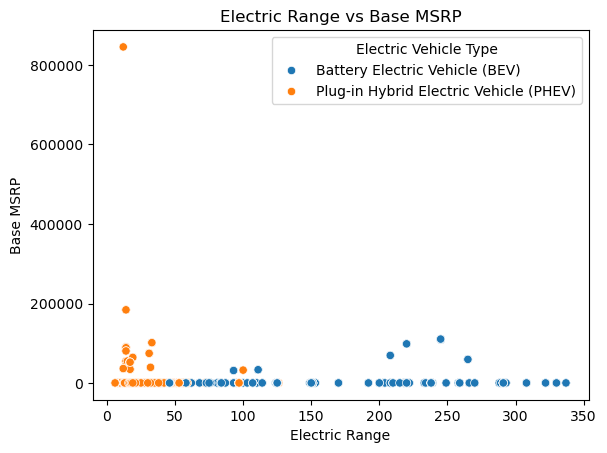

In [56]:
sns.scatterplot(data=EVP_df, x='Electric Range', y='Base MSRP', hue='Electric Vehicle Type')
plt.title('Electric Range vs Base MSRP')
plt.xlabel('Electric Range')
plt.ylabel('Base MSRP')
plt.show()

** **

**Average Electric Range Over Years**

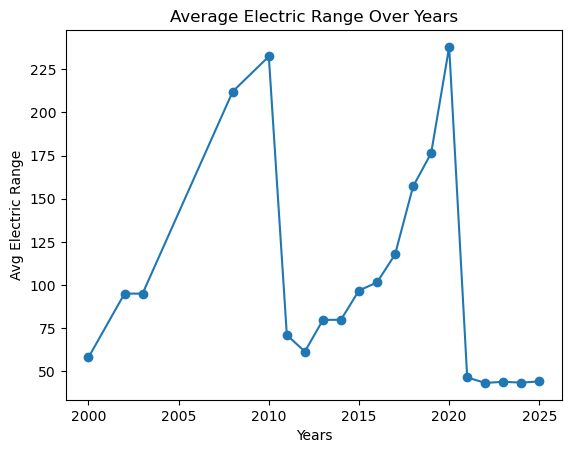

In [174]:
EVP_df.groupby('Model Year')['Electric Range'].mean().plot(kind='line', marker='o')
plt.title("Average Electric Range Over Years")
plt.xlabel("Years")
plt.ylabel("Avg Electric Range")
plt.show()

** **

**Manufacturers Count by Average MSRP**

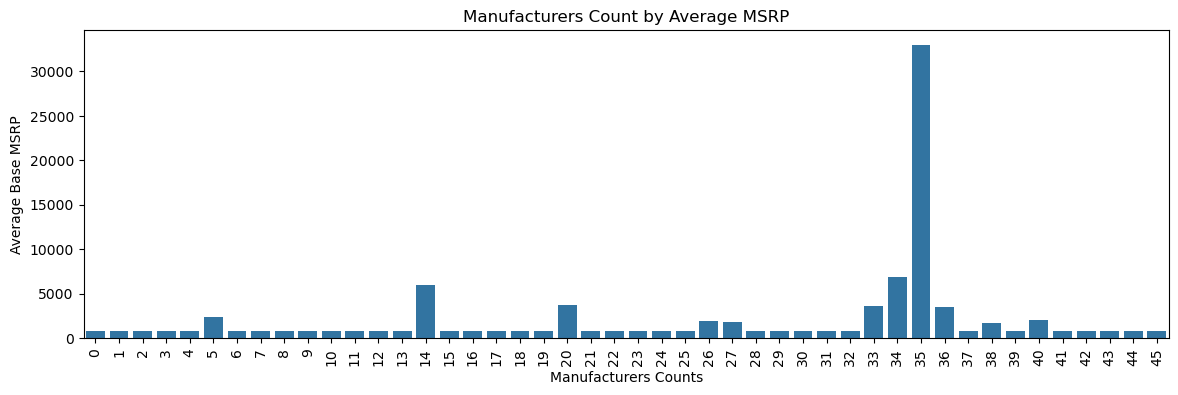

In [173]:
plt.figure(figsize=(14,4))
avg_msrp = EVP_df.groupby('Make')['Base MSRP'].mean().sort_values()
sns.barplot(x=avg_msrp.index, y=avg_msrp.values)
plt.title("Manufacturers Count by Average MSRP")
plt.xlabel("Manufacturers Counts")
plt.ylabel("Average Base MSRP")
plt.xticks(rotation=90)
plt.show()

****

**Modelling**


**Import Library for Modelling**

In [137]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

create binary feature for EV_Type 1 if the vehicle is a Battery Electric Vehicle else 0 

In [138]:
EVP_df['EV_Type'] = EVP_df['Electric Vehicle Type'].apply(lambda x: 1 if 'Battery Electric' in str(x) else 0)

In [139]:
features = ['Model Year','Base MSRP','Electric Range','Legislative District','State','County','Make'] #creating list features.

convert text columns into numeric codes using LabelEncoder

In [140]:
label = LabelEncoder()   #creating object of LabelEncoder class and storing it in the variable label.
for col in ['State', 'County', 'Make']:   #Repeat the encoding process for each columns
    EVP_df[col] = label.fit_transform(EVP_df[col].astype(str))  #replaces the text with its assigned number.

In [141]:
X = EVP_df[features]  #stores all variables in a new variable X
y = EVP_df['EV_Type']  #The value model will try to predict.

divide data into training and testing 

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

**Random Forest Classifier**

In [142]:
Train_Random = RandomForestClassifier(n_estimators=100, random_state=42)  #Creating the model
Train_Random.fit(X_train, y_train) #Train the model

RandomForestClassifier(random_state=42)

In [143]:
y_pred = Train_Random.predict(X_test)   #trained Random Forest model to predict EV types for test data

In [144]:
accuracy_score(y_test, y_pred)  #calculate predictions the model get right

0.9997666475741954

**classification report**

In [69]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9612
           1       1.00      1.00      1.00     37527

    accuracy                           1.00     47139
   macro avg       1.00      1.00      1.00     47139
weighted avg       1.00      1.00      1.00     47139



Random Forest model achieved perfect performance.

It classified all vehicles correctly.

Precision, Recall and F1 are 1.00 for both classes.

**confusion matrix heatmap**

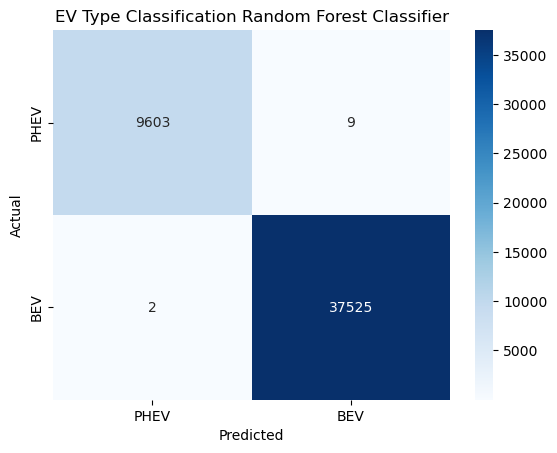

In [145]:
sns.heatmap(confusion_matrix(y_test, y_pred),  #actual confusion matrix data.
            annot=True,  #Adds the numbers inside each box.
            fmt='d',  #Displays annotations as integers.
            cmap='Blues', #Sets the color scheme.
            xticklabels=['PHEV','BEV'],   #Labels for predicted classes. 
            yticklabels=['PHEV','BEV'])   #Labels for actual classes.
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EV Type Classification Random Forest Classifier')
plt.show()

9603 PHEVs correctly predicted as PHEV

Only 9 PHEVs misclassified as BEV

37525 BEVs correctly predicted as BEV

Only 2 BEVs misclassified as PHEV

The Random Forest Classifier achieved 99.9% accuracy in predicting Electric Vehicle Type, correctly classifying nearly all PHEVs and BEVs.

****

**Logistic Regression**

Import Library for LogisticRegression Modelling

In [71]:
from sklearn.linear_model import LogisticRegression

In [146]:
Train_Reg = LogisticRegression(max_iter=1000, random_state=42) #Creating the model
Train_Reg.fit(X_train, y_train) #Train the model

LogisticRegression(max_iter=1000, random_state=42)

In [148]:
y_pred = Train_Reg.predict(X_test)   #train Logistic Regression model to predict EV type

In [149]:
accuracy_score(y_test, y_pred)  #calculate predictions the model get right

0.9522263942807442

**classification report**

In [75]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.77      0.87      9612
           1       0.94      1.00      0.97     37527

    accuracy                           0.95     47139
   macro avg       0.97      0.88      0.92     47139
weighted avg       0.95      0.95      0.95     47139



Model performance 95% accuracy.

Class 1 detected perfectly because Recall is 1.00

Class 0 some missed because Recall is 0.77


**confusion matrix heatmap**

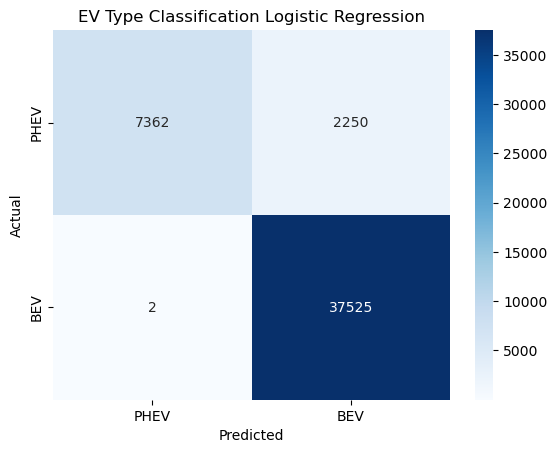

In [150]:
sns.heatmap(confusion_matrix(y_test, y_pred),  # Confusion matrix data
            annot=True,  # Show the numbers on the cells
            fmt='d',   # Format numbers as integers
            cmap='Blues',  # Color theme
            xticklabels=['PHEV','BEV'],   #Labels for predicted classes.
            yticklabels=['PHEV','BEV'])   #Labels for actual classes.
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('EV Type Classification Logistic Regression')
plt.show()

7362 PHEVs were correctly classified as PHEV.

2250 PHEVs were misclassified as BEV.

37525 BEVs were correctly classified as BEV.

Only 2 BEVs were wrongly classified as PHEV.

The Logistic Regression model shows a strong toward BEV as it predicts BEVs more accurately than PHEVs.
BEVs are classified almost perfectly.

****

The project successfully analyzed the Electric Vehicle Population dataset to classify and predict electric vehicle types BEV and PHEV.

The project concluded that Battery Electric Vehicles (BEVs) are more likely to be
CAFV eligible due to higher electric ranges and recent model years.

Random Forest achieved 1.00 accuracy, providing reliable insights into EV adoption
trends and supporting data-driven environmental planning.

Battery Electric Vehicles (BEVs) are more likely to qualify for CAFV programs
compared to Plug-in Hybrid Electric Vehicles (PHEVs).